# WBGT in observations (ISIMIP3a): model eval with obsclim 

Comparing obsclim 2000-2019 with models at same warming level in 20 year period (or 30, you can change it), 

i.e. how similar is frequency of heat stress days in models versus renalysis, calculated in an empirical way, in period 2000-2019 and matching warming level in models 

how similar is mean WBGT in models vs. reanalysis?

**Key results:**
- ERA5 gives lower numbers / WBGT temperatures than W5E5
- Models more similar to W5E5 than ERA5 (bias adjusted against this)
- Generally bias centered on zero, but some models are positively biased (i.e. hotter than reanalysis)


In [1]:
# necessary: netcdf4-python, regionmask, (xarray, geopandas), cartopy, openpyxl, (statsmodels?)

import numpy as np
import pandas as pd
import os, glob, re, sys
import math
import xarray as xr
import geopandas as gpd
import regionmask as regionmask
import dask
import matplotlib.pyplot as plt
import netCDF4

%matplotlib inline

#plotting
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# import my variables settings functions from other scripts
from settings import *

# import fxns 
from functions import *
from utils import *
from plotscript import *




In [2]:
start_message() 

flags: {'models': 'ISIMIP3a', 'experiment': 'obsclim', 'metric': 'WBGT', 'method': 'calculate', 'time_method': None, 'shift_sigma': None, 'shift_period': None, 'shift_loglike': None, 'chunk_version': 0}
var: None
VARs: ['tasmax', 'huss', 'ps']
indir_p: /data/brussel/vo/000/bvo00012/data/dataset/ISIMIP/ISIMIP3b/InputData/climate/atmosphere/bias-adjusted/global/daily/
indir_s: /data/brussel/vo/000/bvo00012/data/dataset/ISIMIP/ISIMIP3b/SecondaryInputData/climate/atmosphere/bias-adjusted/global/daily/
indir_obs: /data/brussel/vo/000/bvo00012/data/dataset/ISIMIP/ISIMIP3a/InputData/climate/atmosphere/obsclim/global/daily/historical/
indir_counterclim: /data/brussel/vo/000/bvo00012/data/dataset/ISIMIP/ISIMIP3a/InputData/climate/atmosphere/counterclim/global/daily/historical/
GCMs: ['CanESM5', 'CNRM-CM6-1', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'MIROC6', 'MRI-ESM2-0', 'EC-Earth3', 'UKESM1-0-LL', 'MPI-ESM1-2-HR', 'CNRM-ESM2-1']
datasets: ['GSWP3-W5E5', '20CRv3-ERA5', '20CRv3-W5E5', '20CRv3']
lat_chunk: 

In [3]:
cellarea = xr.open_dataarray(os.path.join(datadirs,'geo-information/clm45_area.nc4'))
figdir = os.path.join(figdirs, 'fig_feb26')
os.makedirs(figdir, exist_ok=True)


In [4]:
from dask.distributed import Client 
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 23.02 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37703,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 4
Started: Just now,Total memory: 23.02 GiB
Comm: tcp://127.0.0.1:45451,Total threads: 1
Dashboard: http://127.0.0.1:33555/status,Memory: 5.76 GiB
Nanny: tcp://127.0.0.1:41939,


In [5]:
import numpy as np

def rmse_weighted(a, b, cellarea=cellarea, mask=True):
    """
    Calculates RMSE between a forecast, a, and an observation, b, 
    with area weighting using cellarea.
    """
    if mask:
        cellarea = cellarea * landmask
        a = a * landmask
        b = b * landmask 
    weighted_squared_errors = cellarea * (a - b) ** 2
    return np.sqrt(np.sum(weighted_squared_errors) / np.sum(cellarea))

def mae_weighted(a, b, cellarea=cellarea, mask=True):
    """
    Calculates mean absolute error between a and b, 
    with area weighting using cellarea.
    """
    if mask:
        cellarea = cellarea * landmask
        a = a * landmask
        b = b * landmask 
    weighted_absolute_errors = cellarea * np.abs(a - b)
    return np.sum(weighted_absolute_errors) / np.sum(cellarea)

def bias_weighted(a, b, cellarea=cellarea, mask=True):
    """
    Calculates mean bias between a and b, 
    with area weighting using cellarea.
    """
    if mask:
        cellarea = cellarea * landmask
        a = a * landmask
        b = b * landmask 
    weighted_errors = cellarea * (a - b)
    return np.sum(weighted_errors) / np.sum(cellarea)

In [6]:
def calc_sig_mask(p1,p0):

    time = pd.date_range("2000-01-01", "2019-12-31", freq="D")
    n = len(time)

    se = np.sqrt(
        p0 * (1 - p0) / n +
        p1 * (1 - p1) / n
    )

    z = (p1-p0) / se

    sig = np.abs(z) > 1.96

    return sig.squeeze()

# Open data obsclim and models 

In [7]:
datasets

['GSWP3-W5E5', '20CRv3-ERA5', '20CRv3-W5E5', '20CRv3']

In [8]:
datasets_sel = datasets[0:3] 
datasets_sel

['GSWP3-W5E5', '20CRv3-ERA5', '20CRv3-W5E5']

In [9]:
nyrs=20

da_p28_obs, da_p30_obs = [ open_all_wbgt_summary(GCMs=datasets_sel,
                            metric='WBGT',
                            open_what=open_what,
                            outdirpath='../../data/output_jan25/WBGT/',
                            experiment='obsclim',
                            period='present',
                            observations=True,
                            nyrs=nyrs).rename(name) for open_what, name in zip(['pctl28','pctl30'], ['gt28','gt30']) ] # 

da_mean_obs, da_min_obs, da_max_obs, da_std_obs = [ open_all_wbgt_summary(GCMs=datasets_sel,
                            metric='WBGT',
                            open_what=open_what,
                            outdirpath='../../data/output_jan25/WBGT/',
                            experiment='obsclim',
                            period='present',
                            observations=True,
                            nyrs=nyrs).rename(name) \
                                                   for  open_what, name in zip(
                                                                            ['timmean','timmin', 'timmax', 'timstd'], 
                                                                            ['wbgt_mean','wbgt_min', 'wbgt_max', 'wbgt_std']) ] 



2000_2019_pctl28
['../../data/output_jan25/WBGT/WBGT/ISIMIP3a/obsclim/preprocessed/GSWP3-W5E5/gswp3-w5e5_obsclim_2000_2019_pctl28.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3a/obsclim/preprocessed/20CRv3-ERA5/20crv3-era5_obsclim_2000_2019_pctl28.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3a/obsclim/preprocessed/20CRv3-W5E5/20crv3-w5e5_obsclim_2000_2019_pctl28.nc']


2000_2019_pctl30
['../../data/output_jan25/WBGT/WBGT/ISIMIP3a/obsclim/preprocessed/GSWP3-W5E5/gswp3-w5e5_obsclim_2000_2019_pctl30.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3a/obsclim/preprocessed/20CRv3-ERA5/20crv3-era5_obsclim_2000_2019_pctl30.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3a/obsclim/preprocessed/20CRv3-W5E5/20crv3-w5e5_obsclim_2000_2019_pctl30.nc']
2000_2019_timmean
['../../data/output_jan25/WBGT/WBGT/ISIMIP3a/obsclim/preprocessed/GSWP3-W5E5/gswp3-w5e5_obsclim_2000_2019_timmean.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3a/obsclim/preprocessed/20CRv3-ERA5/20crv3-era5_obsclim_2000_2019_timmean.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3a/obsclim/preprocessed/20CRv3-W5E5/20crv3-w5e5_obsclim_2000_2019_timmean.nc']
2000_2019_timmin
['../../data/output_jan25/WBGT/WBGT/ISIMIP3a/obsclim/preprocessed/GSWP3-W5E5/gswp3-w5e5_obsclim_2000_2019_timmin.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3a/obsclim/preprocessed/20CRv3-ERA5/20crv3-era5_obsclim_2000_2019_tim

In [10]:


da_p28_mod, da_p30_mod = [ open_all_wbgt_summary(GCMs=GCMs,
                            metric='WBGT',
                            open_what=open_what,
                            outdirpath='../../data/output_jan25/WBGT/',
                            experiment=None,
                            period='present',
                            observations=False,
                            nyrs=nyrs).rename(name) for open_what, name in zip(['pctl28','pctl30'], ['gt28','gt30']) ]

da_mean_mod, da_min_mod, da_max_mod, da_std_mod = [ open_all_wbgt_summary(GCMs=GCMs,
                            metric='WBGT',
                            open_what=open_what,
                            outdirpath='../../data/output_jan25/WBGT/',
                            experiment=None,
                            period='present',
                            observations=False,
                            nyrs=nyrs).rename(name) \
                                                   for  open_what, name in zip(
                                                                            ['timmean','timmin', 'timmax', 'timstd'], 
                                                                            ['wbgt_mean','wbgt_min', 'wbgt_max', 'wbgt_std']) ] 



2019_20yr_pctl28
['../../data/output_jan25/WBGT/WBGT/ISIMIP3b/preprocessed/CanESM5/canesm5_r1i1p1f1_w5e5_historical_2019_20yr_pctl28.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3b/preprocessed/CNRM-CM6-1/cnrm-cm6-1_r1i1p1f2_w5e5_historical_2019_20yr_pctl28.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3b/preprocessed/GFDL-ESM4/gfdl-esm4_r1i1p1f1_w5e5_historical_2019_20yr_pctl28.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3b/preprocessed/IPSL-CM6A-LR/ipsl-cm6a-lr_r1i1p1f1_w5e5_historical_2019_20yr_pctl28.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3b/preprocessed/MIROC6/miroc6_r1i1p1f1_w5e5_historical_2019_20yr_pctl28.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3b/preprocessed/MRI-ESM2-0/mri-esm2-0_r1i1p1f1_w5e5_historical_2019_20yr_pctl28.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3b/preprocessed/EC-Earth3/ec-earth3_r1i1p1f1_w5e5_historical_2019_20yr_pctl28.nc']
['../../data/output_jan25/WBGT/WBGT/ISIMIP3b/preprocessed/UKESM1-0-LL/ukesm1-0-ll_r1i1p1f2_w5e5_historical_2

# 1) Number of days crossing WBGT28 in present-day (2000-2019): models v. obs

Possibly calcuate summary stats only between -40 and 40 lat

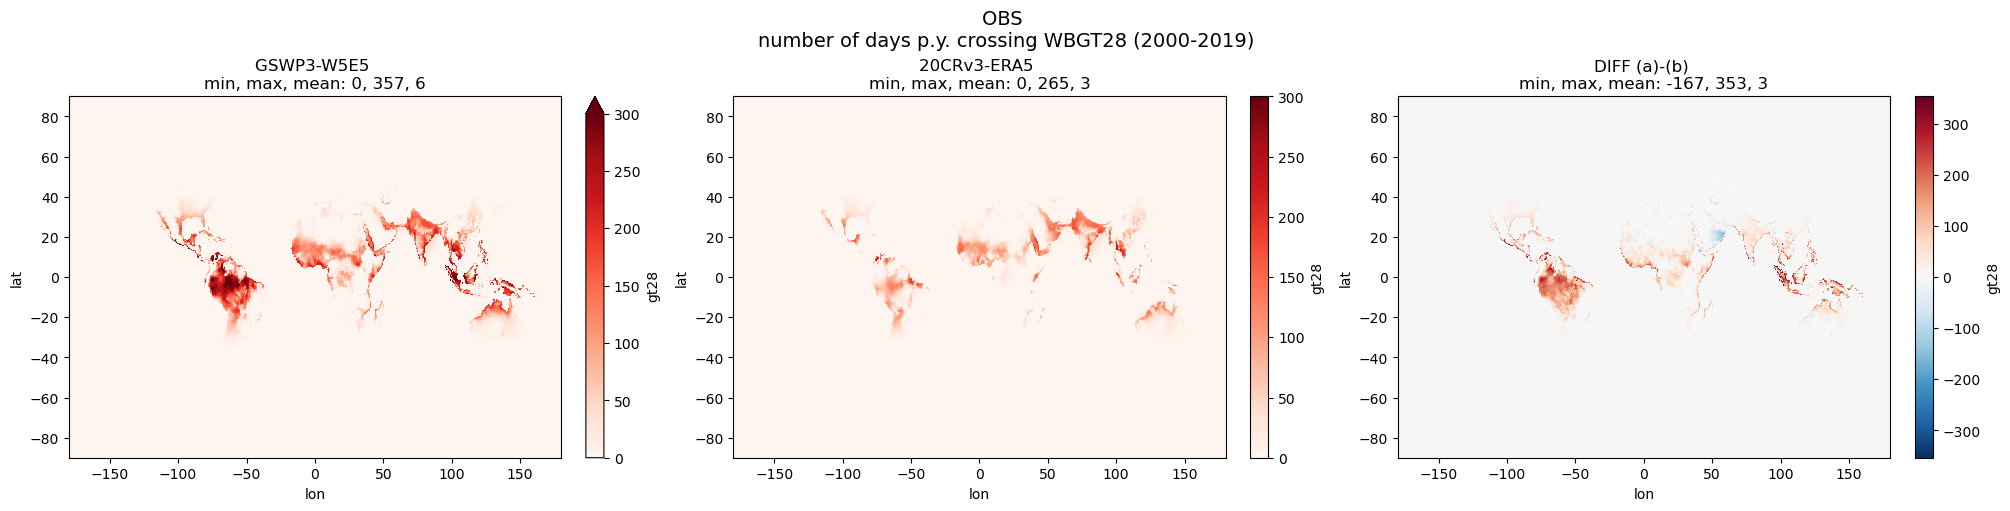

In [11]:
fig, axes = plt.subplots(1,3, figsize=(20,5),  layout='constrained')
axes = axes.flatten() 
vmax=300

for i,ax in enumerate(axes):
    if i < 2:
        data_plot= da_p28_obs.isel(model=i)  * 365
        data_plot.plot(ax=ax, vmax=vmax, cmap='Reds')
        ax.set_title(f'{data_plot.model.values} \nmin, max, mean: {data_plot.min().item():.0f}, {data_plot.max().item():.0f}, {data_plot.mean().item():.0f}')
    if i == 2:
        data_plot= (da_p28_obs.isel(model=0) - da_p28_obs.isel(model=1))  * 365
        data_plot.plot(ax=ax)
        ax.set_title(f'DIFF (a)-(b) \nmin, max, mean: {data_plot.min().item():.0f}, {data_plot.max().item():.0f}, {data_plot.mean().item():.0f}')

fig.suptitle('OBS \nnumber of days p.y. crossing WBGT28 (2000-2019)',size=14);

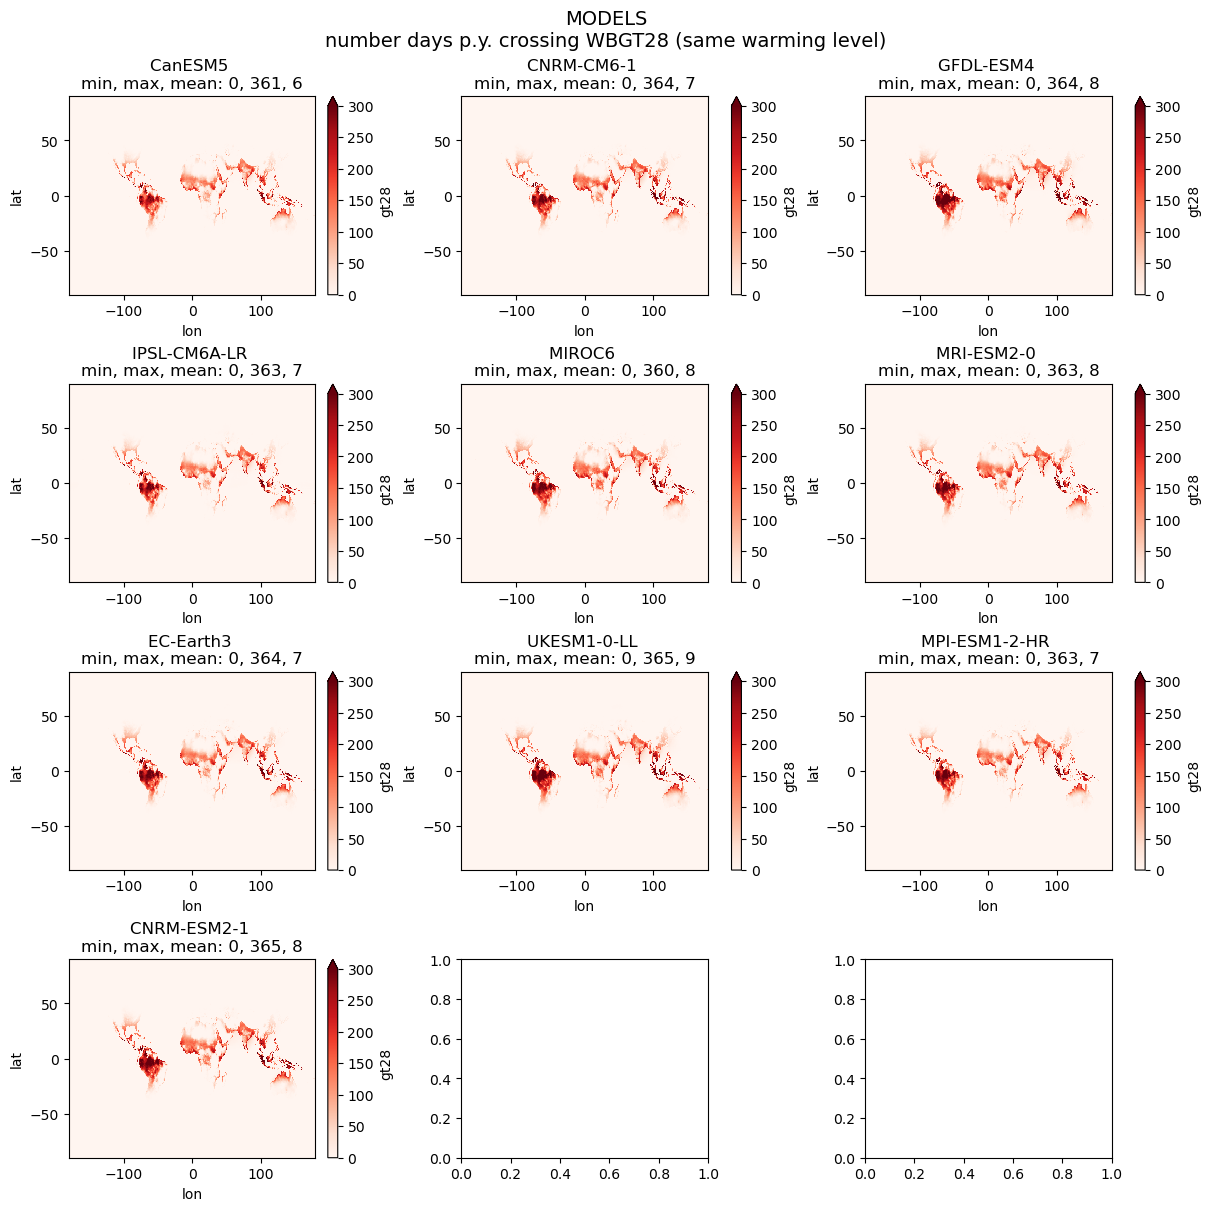

In [12]:
fig, axes = plt.subplots(4,3, figsize=(12,12),  layout='constrained')
axes = axes.flatten() 
vmax=300

for i,ax in zip(range(len(GCMs)), axes):
    data_plot= da_p28_mod.isel(model=i)  * 365
    data_plot.plot(ax=ax, vmax=vmax, cmap='Reds')
    ax.set_title(f'{data_plot.model.values.item()} \nmin, max, mean: {data_plot.min().item():.0f}, {data_plot.max().item():.0f}, {data_plot.mean().item():.0f}')

fig.suptitle('MODELS\nnumber days p.y. crossing WBGT28 (same warming level)',size=14);

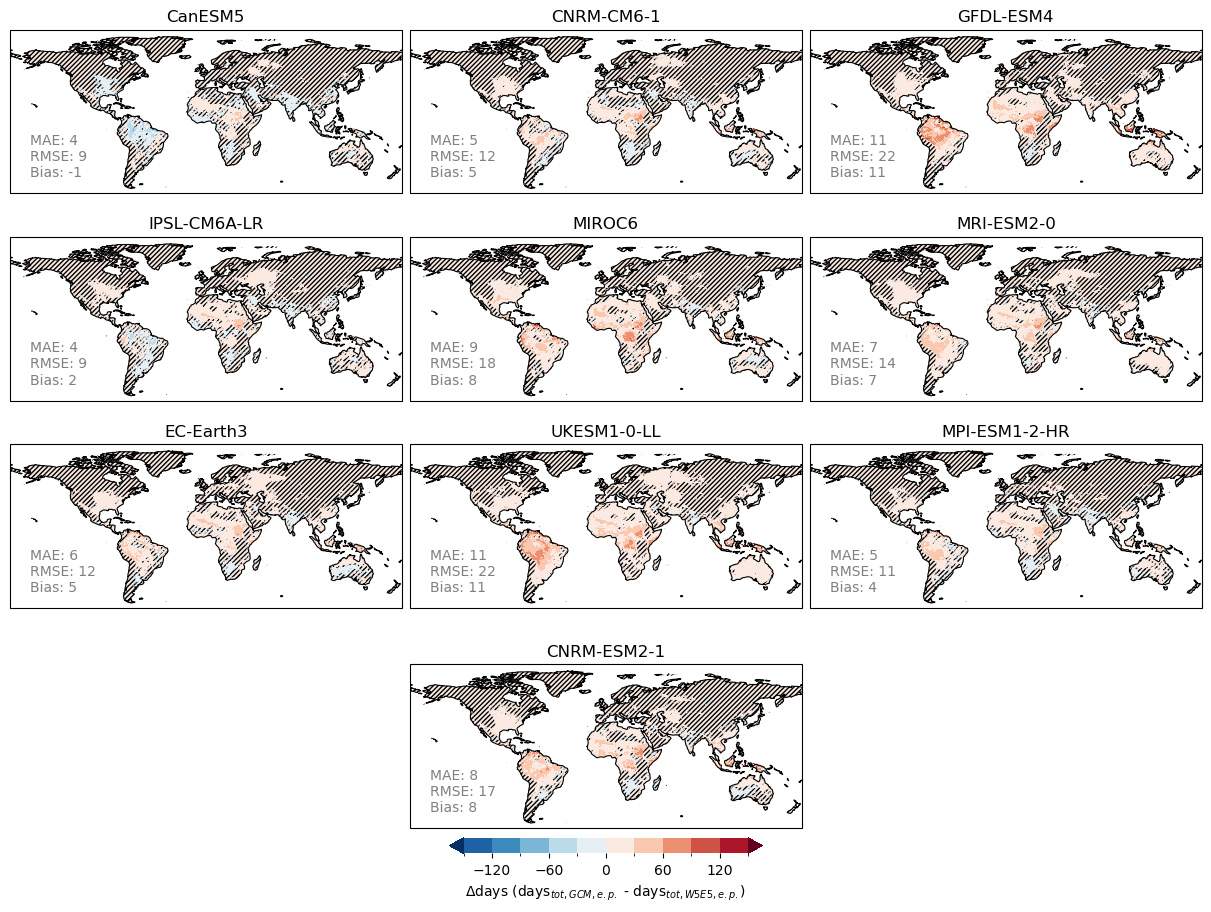

In [ ]:

vmax = 150
landmask = get_mask()
crs = ccrs.PlateCarree()
levels=np.linspace(-vmax,vmax,11)

fig, axes = plt.subplots(4,3, figsize=(12,9),  layout='constrained',subplot_kw={'projection': crs})
axes = axes.flatten() 

#for i,ax in zip(range(len(GCMs)), axes):

for i, ax in enumerate( np.concatenate((axes[:len(GCMs)-1], [axes[-2]])) ):
    if i >= 10:
        break

    ax.set_extent([-179.75, 179.75, -60, 90], crs=ccrs.PlateCarree())

    data1=da_p28_mod.isel(model=i)
    data2=da_p28_obs.isel(model=0)
    data_plot= (data1 - data2) * 365 *landmask


    # calc statistics 
    rmse= rmse_weighted(data1, data2, cellarea=cellarea, mask=True) *365
    mae = mae_weighted(data1, data2, cellarea=cellarea, mask=True) *365
    bias= bias_weighted(data1, data2, cellarea=cellarea, mask=True) *365

    # plot 
    plot = data_plot.plot(ax=ax, vmax=vmax,extend='both',add_colorbar=False,levels=levels)
    ax.coastlines(color='black', linewidth=0.8)


    # stippling - delete this to have without significance assessment
    sig = calc_sig_mask(data1,data2)
    # option b: hatch = n.s.
    sig_inv = ~sig
    cont = ax.contourf(sig.lon, sig.lat, sig_inv.where(landmask==1,False).values, hatches=['', '///////'],  colors=['none'])


    ax.set_title(f'{da_p28_mod.isel(model=i).model.values.item()}')
    ax.text(.05,.1, 
        f"MAE: {int(mae.values.round(0))}\n"
        f"RMSE: {int(rmse.values.round(0))}\n"
        f"Bias: {int(bias.values.round(0))}" ,
        transform=ax.transAxes,
        c='gray')

# add title and cbar
#fig.suptitle('$\Delta$MODEL-OBS (a, W5E5) \nnumber of days crossing WBGT28 (2000-2019 vs. same warming)', size=14);
cbar = fig.colorbar(plot, extend='both', ax=ax, location='bottom', shrink=1, fraction=0.08)
cbar.set_label('$\Delta$days (days$_{tot,GCM,e.p.}$ - days$_{tot,W5E5,e.p.}$)', )
cbar.outline.set_edgecolor('none')

# Remove the two empty subplots
for ax in (axes[-3], axes[-1]):
    ax.remove()

# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSImodeleval_ndays_wbgt28_20years_map_lvls_significant.png'),dpi=300,transparent=True)

min, max, mean: -0.2, 0.2, -0.0
min, max, mean: -0.1, 0.3, 0.0
min, max, mean: -0.0, 0.5, 0.0
min, max, mean: -0.2, 0.3, 0.0
min, max, mean: -0.1, 0.4, 0.0
min, max, mean: -0.1, 0.3, 0.0
min, max, mean: -0.1, 0.3, 0.0
min, max, mean: -0.1, 0.5, 0.0
min, max, mean: -0.1, 0.3, 0.0
min, max, mean: -0.1, 0.4, 0.0


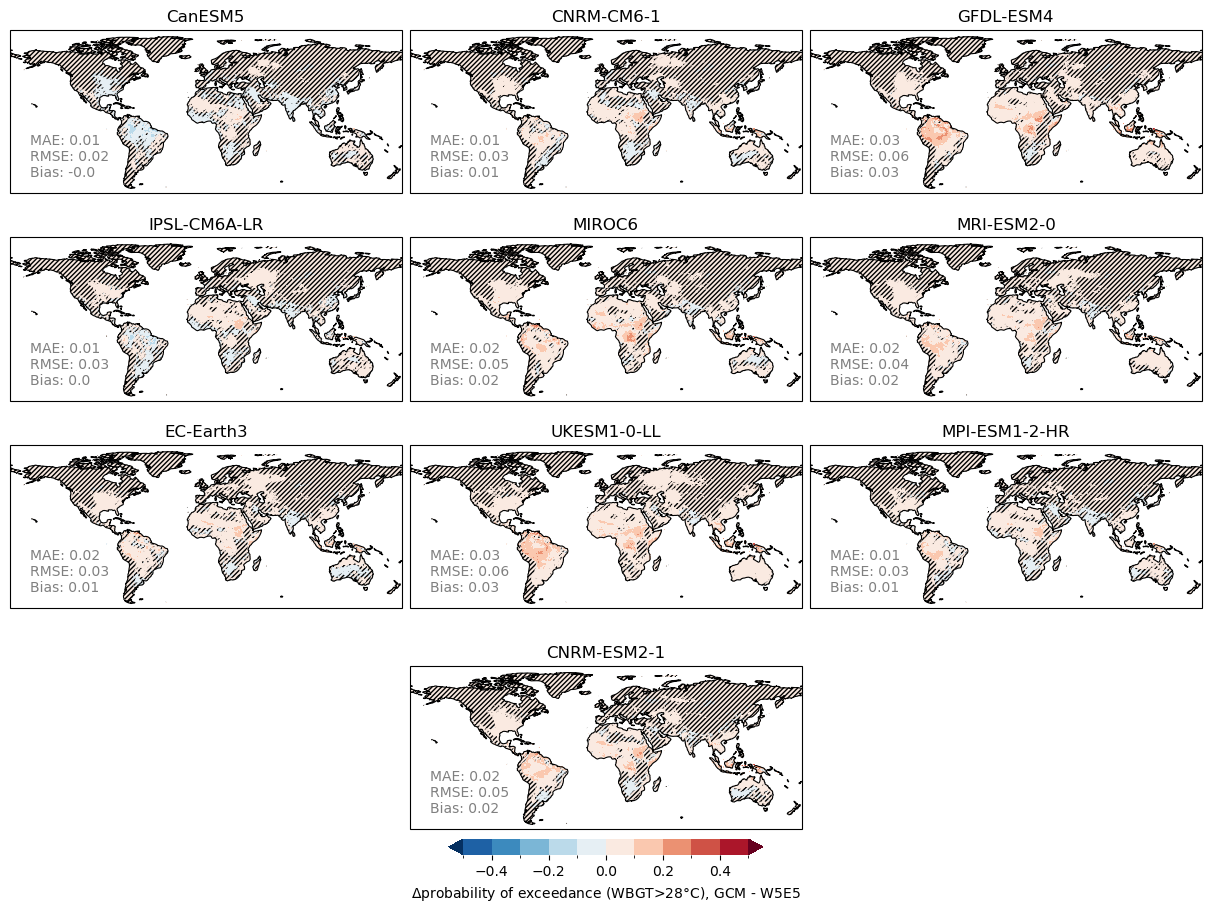

In [ ]:

vmax = .5
landmask = get_mask()
crs = ccrs.PlateCarree()

fig, axes = plt.subplots(4,3, figsize=(12,9),  layout='constrained',subplot_kw={'projection': crs})
axes = axes.flatten() 
levels=np.linspace(-vmax,vmax,11)

for i, ax in enumerate( np.concatenate((axes[:len(GCMs)-1], [axes[-2]])) ):
    if i >= 10:
        break

    ax.set_extent([-179.75, 179.75, -60, 90], crs=ccrs.PlateCarree())

    data1=da_p28_mod.isel(model=i)
    data2=da_p28_obs.isel(model=0)
    data_plot= (data1 - data2)  *landmask

    # calc statistics 
    rmse= rmse_weighted(data1, data2, cellarea=cellarea, mask=True) 
    mae = mae_weighted(data1, data2, cellarea=cellarea, mask=True) 
    bias= bias_weighted(data1, data2, cellarea=cellarea, mask=True) 

    # plot 
    plot = data_plot.plot(ax=ax, vmax=vmax, extend='both', add_colorbar=False, levels=levels)
    ax.coastlines(color='black', linewidth=0.8)

    # stippling - delete this to have without significance assessment
    sig = calc_sig_mask(data1,data2)

    # option a : stippling = signficant
    #ax.contourf(sig.lon, sig.lat, sig.where(landmask==1,False).values, hatches=['', '......'], alpha=0)

    # option b: hatch = n.s.
    sig_inv = ~sig
    cont = ax.contourf(sig.lon, sig.lat, sig_inv.where(landmask==1,False).values, hatches=['', '///////'],  colors=['none'])


    # annotation
    ax.set_title(f'{da_p28_mod.isel(model=i).model.values.item()}')
    ax.text(.05,.1, 
        f"MAE: {mae.values.round(2)}\n"
        f"RMSE: {rmse.values.round(2)}\n"
        f"Bias: {bias.values.round(2)}" ,
        transform=ax.transAxes,
        c='gray')


    print(f'min, max, mean: {data_plot.min().item():.1f}, {data_plot.max().item():.1f}, {data_plot.mean().item():.1f}')

# add title and cbar
cbar = fig.colorbar(plot,  ax=ax, location='bottom', shrink=1, fraction=0.08)
cbar.set_label('$\Delta$probability of exceedance (WBGT>28°C), GCM - W5E5', )
cbar.outline.set_edgecolor('none')

# Remove the two empty subplots
for ax in (axes[-3], axes[-1]):
    ax.remove()

# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSImodeleval_probofexceedance_wbgt28_20years_map_lvls_significant.png'),dpi=300)

In [74]:
savefigs=True

In [ ]:
# correct for false discovery rate - OPTIONAL made no difference because of large n when I tested it 

from scipy.stats import norm

pvals = 2 * (1 - norm.cdf(np.abs(z)))
pvals_1d = pvals.ravel()
valid = np.isfinite(pvals_1d)

pvals_valid = pvals_1d[valid]

q = 0.05

# sort p-values
idx = np.argsort(pvals_valid)
p_sorted = pvals_valid[idx]

m = p_sorted.size
thresholds = q * np.arange(1, m + 1) / m

# find largest p-value that satisfies BH condition
passed = p_sorted <= thresholds

if passed.any():
    kmax = np.where(passed)[0].max()
    p_crit = p_sorted[kmax]
else:
    p_crit = 0.0

sig_fdr = pvals <= p_crit

sig_fdr = xr.DataArray(
    sig_fdr,
    coords=sig.coords,
    dims=sig.dims,
    name="sig_fdr"
)

## Times when models were mapped to 

Models mapped further back in past (hot models, CanESM5,IPSL) are possibly over-corrected, and give a bit cold results (CanESM gives cold, IPSL doesn't have a huge systematic bias). 

Models mapped into the future (cold models, GFDL, MIROC) are generally hot in terms of WBGT. 

MRI and CNRM are near the right year and are a bit hot. 


In [35]:
df_gmtmap=pd.read_csv(os.path.join('../../output/output_gmt-mapping/df_gmt_mapping_endyear2019_eval.csv'))
df_gmtmap

,model,10_yr,20_yr,30_yr
0,obs,2019,2019,2019
1,CanESM5,2004,2008,2009
2,CNRM-CM6-1,2021,2021,2020
3,GFDL-ESM4,2029,2029,2029
4,IPSL-CM6A-LR,2009,2010,2011
5,MIROC6,2034,2034,2033
6,MRI-ESM2-0,2021,2022,2024


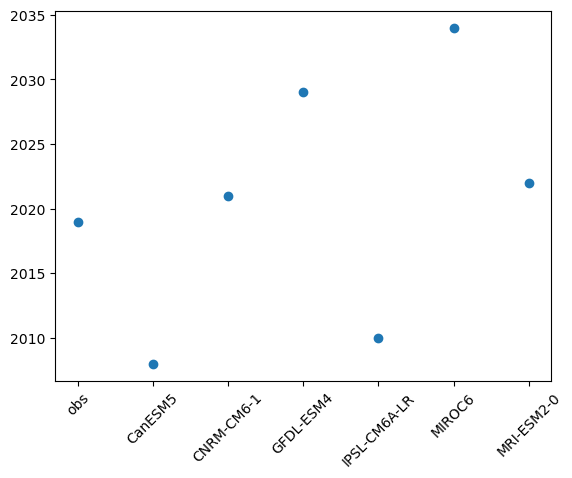

In [36]:
df_gmtmap['20_yr'].plot(linestyle="",marker="o")
plt.xticks(range(7),df_gmtmap.model, rotation=45);

## hist and scatterplot MODELS v. OBS restricted 40 N / 40 S and W5E5

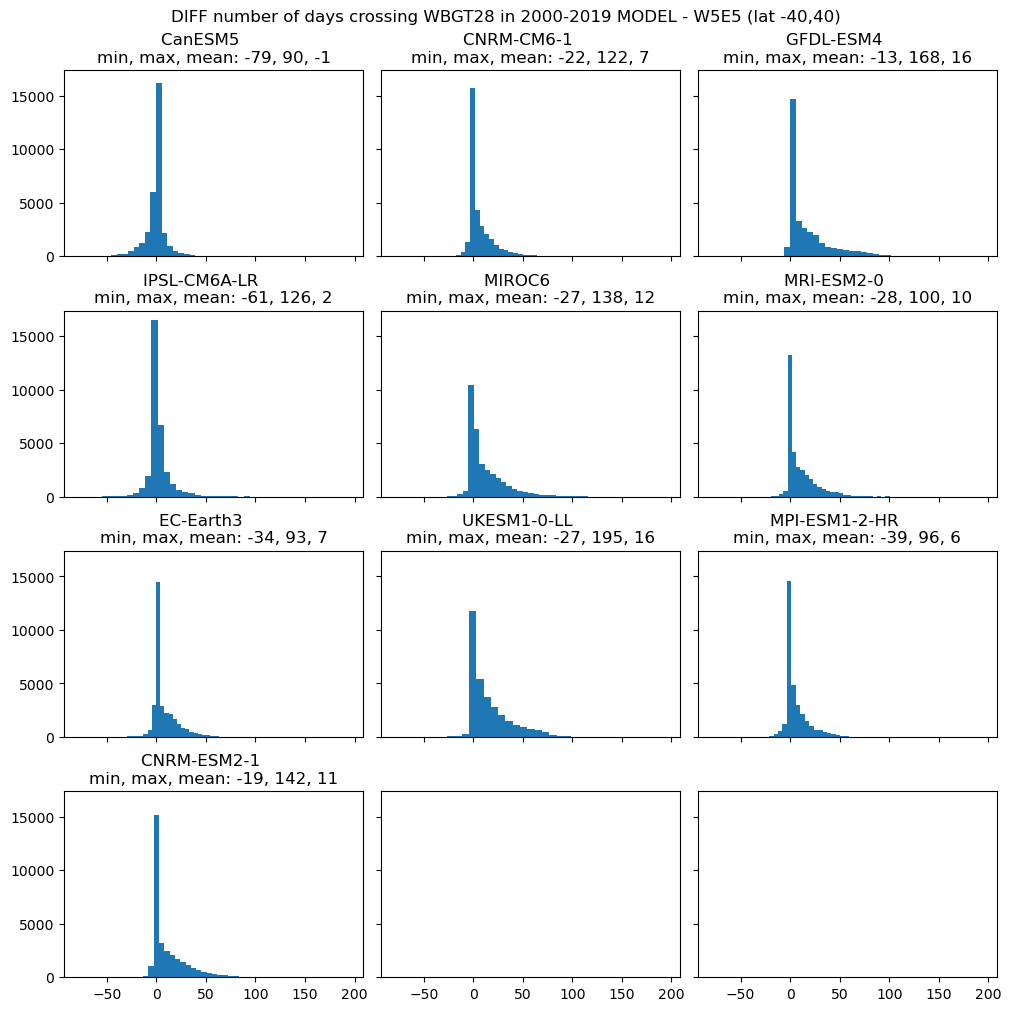

In [37]:
fig, axes = plt.subplots(4,3, figsize=(10,10),  layout='constrained', sharex=True, sharey=True)
axes = axes.flatten() 
vmax = 100
landmask = get_mask()

for i,ax in zip(range(len(GCMs)), axes):
    data_plot= (da_p28_mod.isel(model=i).sel(lat=slice(40,-40)) - da_p28_obs.isel(model=0)).sel(lat=slice(40,-40)) * 365 * landmask
    data_plot.plot.hist(ax=ax, bins=30)
    ax.set_title(f'{da_p28_mod.isel(model=i).model.values.item()} \
    \nmin, max, mean: {data_plot.min().item():.0f}, {data_plot.max().item():.0f}, {data_plot.mean().item():.0f}')

fig.suptitle('DIFF number of days crossing WBGT28 in 2000-2019 MODEL - W5E5 (lat -40,40)');

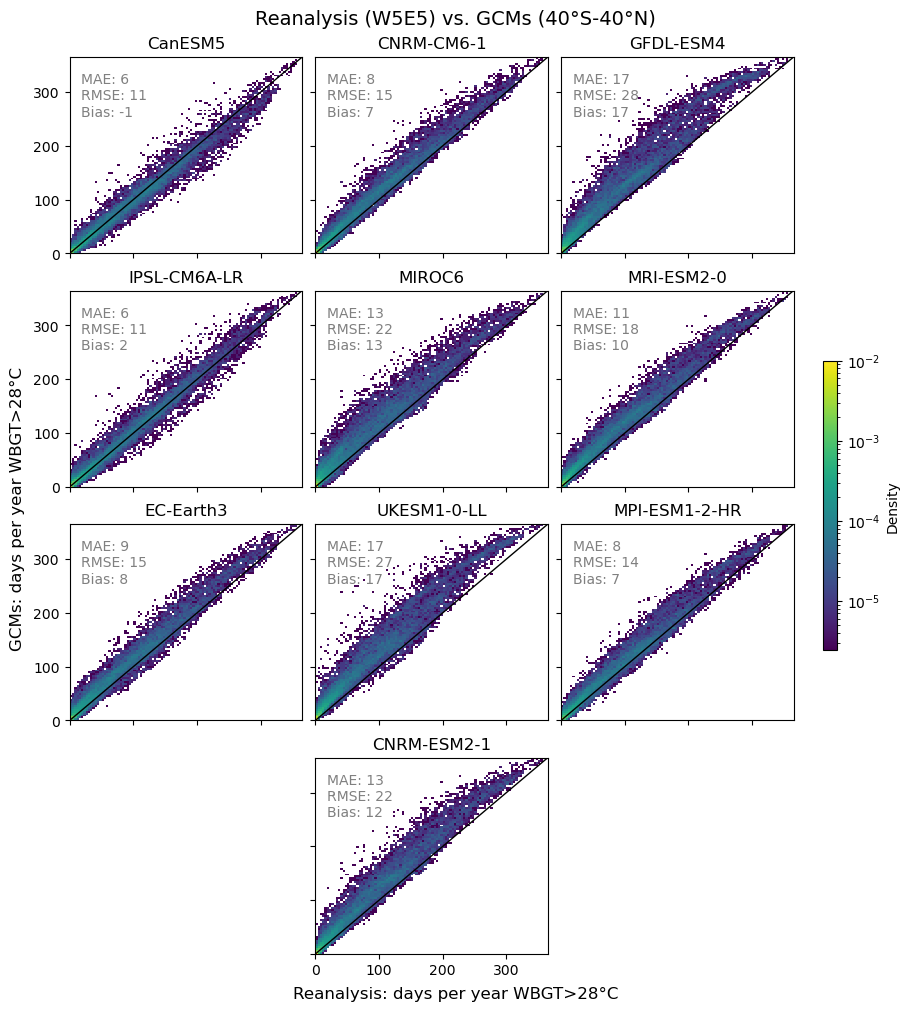

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors

fig, axes = plt.subplots(4, 3, figsize=(9, 10), constrained_layout=True, sharex=True, sharey=True)
axes = axes.flatten()
vmax = .01

# Collect all histograms for shared colorbar scaling
hist_data = []

cellarea_sel = cellarea.sel(lat=slice(40, -40))

# Plot data on the first 10 axes, ignore the last two
for i, ax in enumerate( np.concatenate((axes[:len(GCMs)-1], [axes[-2]])) ):
    if i >= 10:
        break
    data1 =da_p28_obs.isel(model=0).sel(lat=slice(40,-40)) * 365 * landmask
    data2 = da_p28_mod.isel(model=i).sel(lat=slice(40,-40))  * 365 * landmask
    
    x = data1.values.flatten()
    y = data2.values.flatten()
    xy = np.column_stack([x, y])
    xy = xy[~np.isnan(xy).any(axis=1)]
    
    h = ax.hist2d(xy[:, 0], xy[:, 1], bins=100, density=True, norm=colors.LogNorm(vmax=vmax) )
    hist_data.append(h[3])  # Store the mappable object for colorbar scaling

    ax.axline((0, 0), slope=1, color='k', linewidth=1)
    ax.set_title(f'{data2.model.values.item()}')
    ax.set_ylim([0,365])
    ax.set_xlim([0,365])
    ax.text(.05,.7, 
            f"MAE: {int(mae_weighted(data2, data1, cellarea_sel ).values.round(0))}\n"
            f"RMSE: {int(rmse_weighted(data2, data1, cellarea_sel).values.round(0))}\n"
            f"Bias: {int(bias_weighted(data2, data1, cellarea_sel).values.round(0))}" ,
            transform=ax.transAxes,
            c='gray')

# Add a single colorbar shared across all subplots
cbar = fig.colorbar(hist_data[0], ax=axes[:len(GCMs)], orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label('Density')

# Remove the two empty subplots
for ax in (axes[-3], axes[-1]):
    ax.remove()

fig.suptitle('Reanalysis (W5E5) vs. GCMs (40°S-40°N)',fontsize=14)
fig.supxlabel('Reanalysis: days per year WBGT>28°C')
fig.supylabel('GCMs: days per year WBGT>28°C ');


#plt.savefig(os.path.join(figdir,'figSI14_modeleval_rp_wbgt28_20years.pdf'),dpi=300,transparent=True)
#plt.savefig(os.path.join(figdir,'figSI14_modeleval_rp_wbgt28_20years.png'),dpi=300,transparent=True)



# 2) Mean WBGT

Biases generally within +/- 2 degrees 

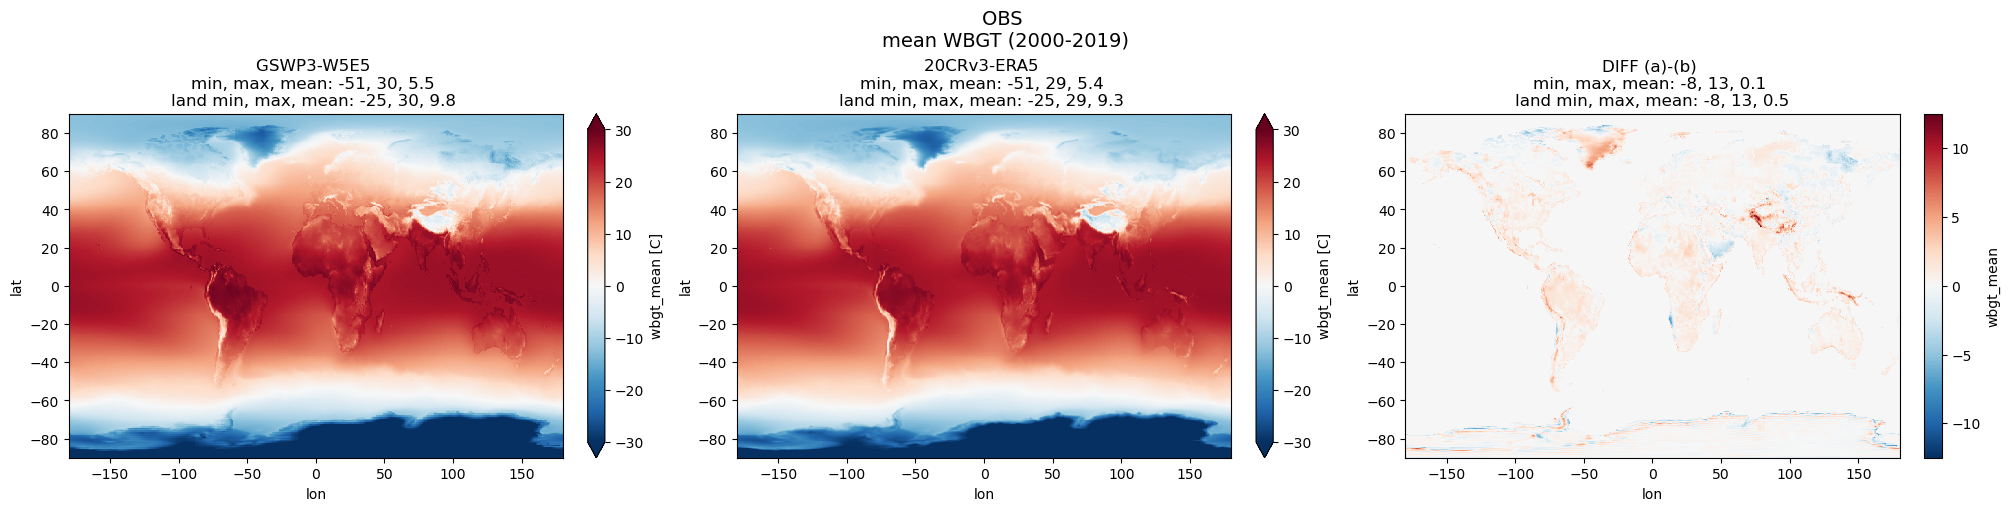

In [18]:
fig, axes = plt.subplots(1,3, figsize=(20,5),  layout='constrained')
axes = axes.flatten() 
vmax=30

for i,ax in enumerate(axes):
    if i < 2:
        data_plot= da_mean_obs.isel(model=i)
        data_plot.plot(ax=ax,vmax=vmax,extend='both')
        ax.set_title(f'{data_plot.model.values} \nmin, max, mean: {data_plot.min().item():.0f}, {data_plot.max().item():.0f}, {data_plot.mean().item():.1f} \nland min, max, mean: {(data_plot*landmask).min().item():.0f}, {(data_plot*landmask).max().item():.0f}, {(data_plot*landmask).mean().item():.1f} ')
    if i == 2:
        data_plot= (da_mean_obs.isel(model=0) - da_mean_obs.isel(model=1)) 
        data_plot.plot(ax=ax)
        ax.set_title(f'DIFF (a)-(b) \nmin, max, mean: {data_plot.min().item():.0f}, {data_plot.max().item():.0f}, {data_plot.mean().item():.1f} \nland min, max, mean: {(data_plot*landmask).min().item():.0f}, {(data_plot*landmask).max().item():.0f}, {(data_plot*landmask).mean().item():.1f}')

fig.suptitle('OBS \nmean WBGT (2000-2019)',size=14);

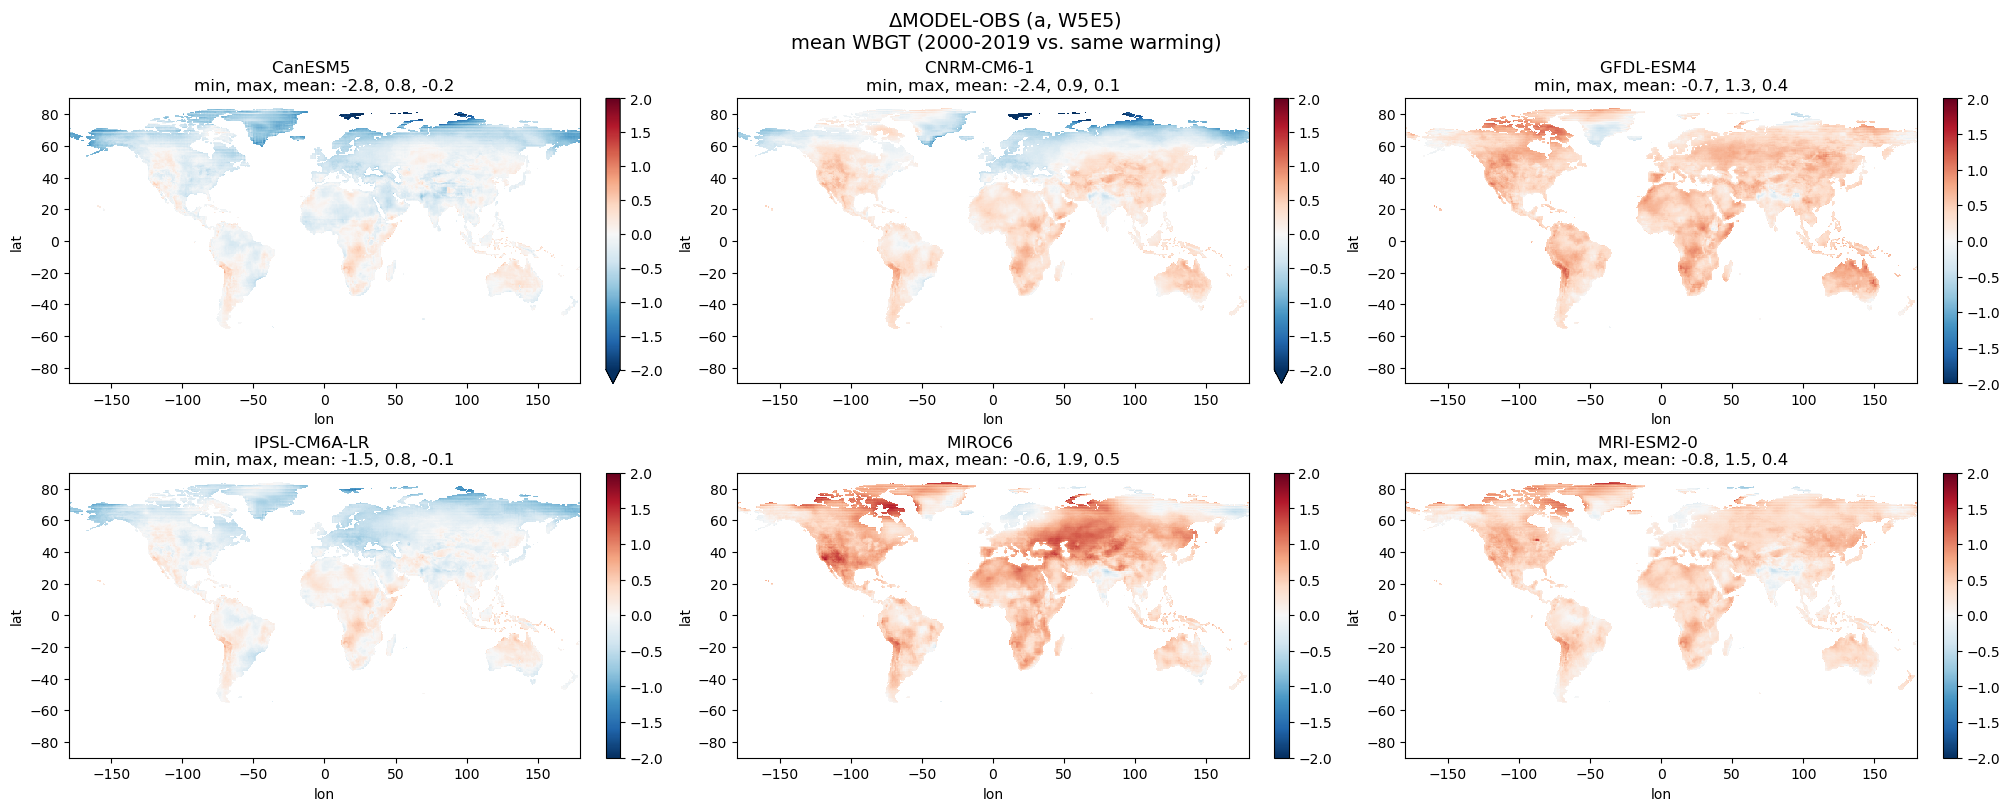

In [19]:
fig, axes = plt.subplots(2,3, figsize=(20,8),  layout='constrained')
axes = axes.flatten() 
vmax=2
landmask = get_mask()

for i,ax in zip(range(len(GCMs)), axes):
    data_plot= (da_mean_mod.isel(model=i) - da_mean_obs.isel(model=0)) *landmask
    data_plot.plot(ax=ax,vmax=vmax)
    ax.set_title(f'{da_p28_mod.isel(model=i).model.values.item()} \
    \nmin, max, mean: {data_plot.min().item():.1f}, {data_plot.max().item():.1f}, {data_plot.mean().item():.1f}')

fig.suptitle('$\Delta$MODEL-OBS (a, W5E5) \nmean WBGT (2000-2019 vs. same warming)', size=14);

min, max, mean: -2.8, 0.8, -0.2
min, max, mean: -2.4, 0.9, 0.1
min, max, mean: -0.7, 1.3, 0.4
min, max, mean: -1.5, 0.8, -0.1
min, max, mean: -0.6, 1.9, 0.5
min, max, mean: -0.8, 1.5, 0.4
min, max, mean: -0.7, 2.3, 0.4
min, max, mean: -1.1, 2.5, 0.6
min, max, mean: -1.2, 0.9, 0.1
min, max, mean: -2.1, 1.6, 0.3


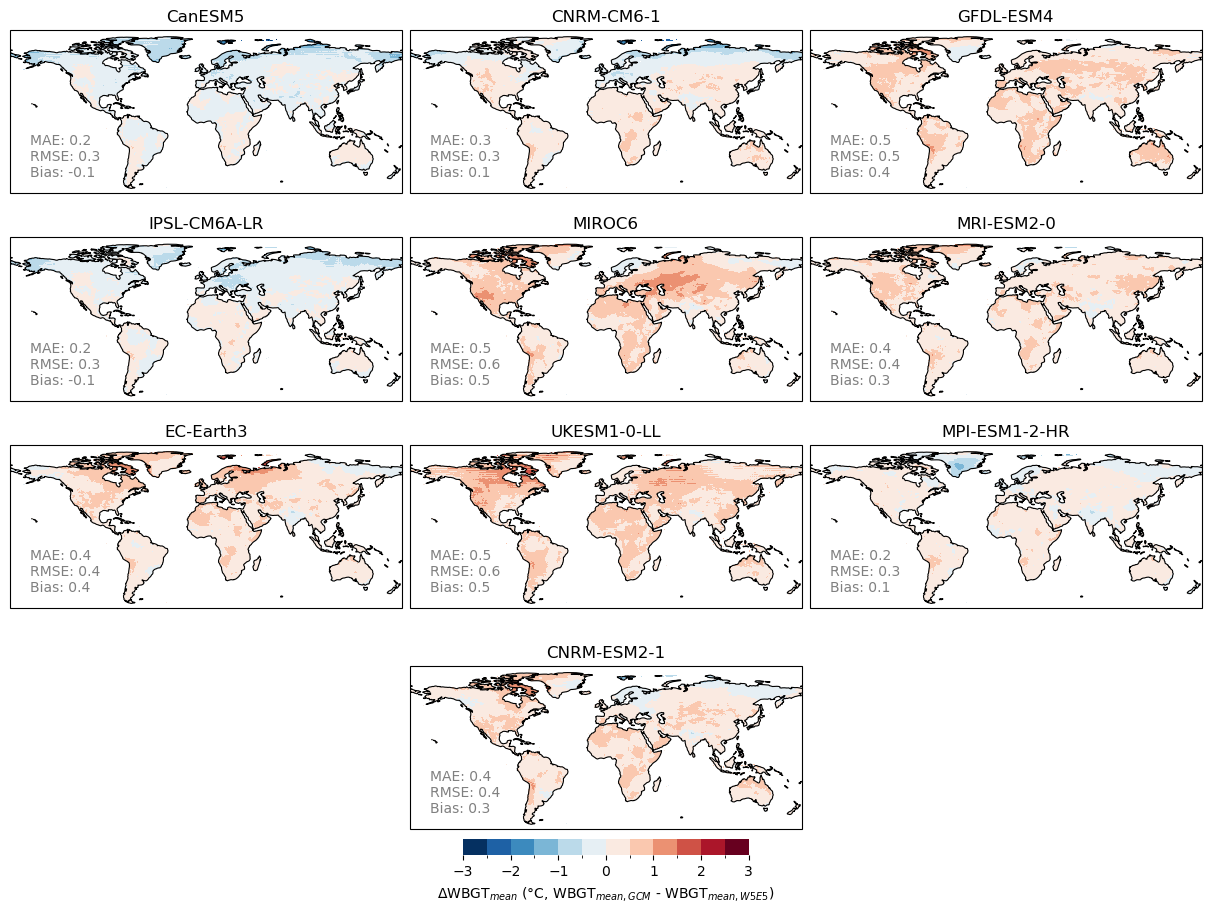

In [109]:

vmax = 3
landmask = get_mask()
crs = ccrs.PlateCarree()

fig, axes = plt.subplots(4,3, figsize=(12,9),  layout='constrained',subplot_kw={'projection': crs})
axes = axes.flatten() 

#for i,ax in zip(range(len(GCMs)), axes):

for i, ax in enumerate( np.concatenate((axes[:len(GCMs)-1], [axes[-2]])) ):
    if i >= 10:
        break

    ax.set_extent([-179.75, 179.75, -60, 90], crs=ccrs.PlateCarree())

    data1=da_mean_mod.isel(model=i) 
    data2=da_mean_obs.isel(model=0)
    data_plot= (data1 - data2) *landmask


    # calc statistics 
    rmse= rmse_weighted(data1, data2, cellarea=cellarea, mask=True) 
    mae = mae_weighted(data1, data2, cellarea=cellarea, mask=True) 
    bias= bias_weighted(data1, data2, cellarea=cellarea, mask=True) 

    # plot 
    plot = data_plot.plot(ax=ax, vmax=vmax, add_colorbar=False, levels=13)
    ax.coastlines(color='black', linewidth=0.8)

    ax.set_title(f'{da_p28_mod.isel(model=i).model.values.item()}')
    ax.text(.05,.1, 
        f"MAE: {mae.values.round(1)}\n"
        f"RMSE: {rmse.values.round(1)}\n"
        f"Bias: {bias.values.round(1)}" ,
        transform=ax.transAxes,
        c='gray')

    print(f'min, max, mean: {data_plot.min().item():.1f}, {data_plot.max().item():.1f}, {data_plot.mean().item():.1f}')

# add title and cbar
#fig.suptitle('$\Delta$MODEL-OBS (a, W5E5) \nnumber of days crossing WBGT28 (2000-2019 vs. same warming)', size=14);
cbar = fig.colorbar(plot, extend='both', ax=ax, location='bottom', shrink=1, fraction=0.08)
cbar.set_label('$\Delta$WBGT$_{mean}$ ($\degree$C, WBGT$_{mean,GCM}$ - WBGT$_{mean,W5E5}$)', )
cbar.outline.set_edgecolor('none')

# Remove the two empty subplots
for ax in (axes[-3], axes[-1]):
    ax.remove()

# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSImodeleval_wbgt_mean_20years_map.png'),dpi=300,transparent=True)

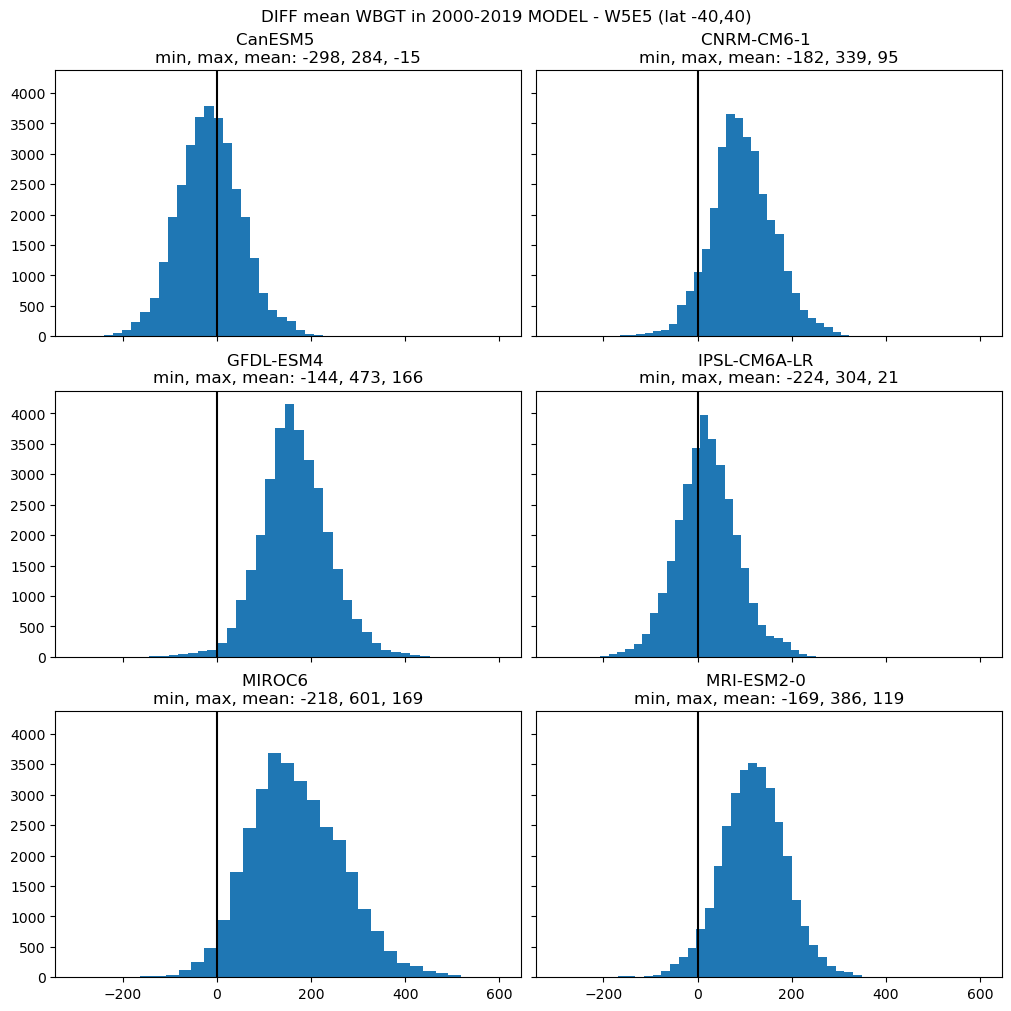

In [21]:
fig, axes = plt.subplots(3,2, figsize=(10,10),  layout='constrained', sharex=True, sharey=True)
axes = axes.flatten() 
landmask = get_mask()

for i,ax in zip(range(len(GCMs)), axes):
    data_plot= (da_mean_mod.isel(model=i).sel(lat=slice(40,-40)) - da_mean_obs.isel(model=0)).sel(lat=slice(40,-40)) * 365 * landmask
    data_plot.plot.hist(ax=ax, bins=30)
    ax.axvline(0,c='k')
    ax.set_title(f'{da_p28_mod.isel(model=i).model.values.item()} \
    \nmin, max, mean: {data_plot.min().item():.0f}, {data_plot.max().item():.0f}, {data_plot.mean().item():.0f}')

fig.suptitle('DIFF mean WBGT in 2000-2019 MODEL - W5E5 (lat -40,40)');